# 01 — Esplorazione del dataset IoT

## Obiettivi didattici

1. Comprendere la struttura del dataset (16 asset, 10 giorni, 1 minuto di sampling).
2. Identificare i tre tipi di colonne: **sensoriali**, **di contesto**, **label**.
3. Quantificare i valori mancanti e visualizzare la copertura temporale.
4. Verificare la regolarità del campionamento (1 minuto = 1 campione, sempre).
5. Visualizzare la prevalenza di anomalie e fault per asset/regime.


In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110
from iot_anomaly.data import load_raw
from iot_anomaly.config import SENSOR_COLUMNS, CONTEXT_COLUMNS, LABEL_COLUMNS


In [2]:
df = load_raw()
print(f'Shape: {df.shape}')
print(f'Periodo: {df.timestamp.min()} → {df.timestamp.max()}')
print(f'Asset: {df.asset_id.nunique()}, regime: {df.regime.nunique()}')
df.head(3)

Shape: (230400, 19)
Periodo: 2025-02-01 00:00:00+00:00 → 2025-02-10 23:59:00+00:00
Asset: 16, regime: 3


,timestamp,asset_id,regime,ambient_temp_c,humidity_pct,load_pct,rpm,current_a,pressure_bar,flow_lpm,temp_c,vib_rms,vib_crest,vib_kurtosis,fault_code_true,fault_type_true,anomaly_label,site_id,line_id
0,2025-02-01 00:00:00+00:00,0,0,19.564531,44.851517,0.0,0.0,0.098240,0.008127,0.000000,19.709127,0.017158,2.421915,3.521426,0,normal,0,0,0
1,2025-02-01 00:01:00+00:00,0,0,18.823996,35.825134,0.0,0.0,0.054512,0.015085,0.103671,19.053288,0.012610,2.548536,3.573378,0,normal,0,0,0
2,2025-02-01 00:02:00+00:00,0,0,18.942278,39.925632,0.0,0.0,0.040504,0.068128,0.107705,18.812178,0.012175,2.245433,2.655908,0,normal,0,0,0


## Le tre famiglie di colonne

**Sensoriali** (caratterizzano lo stato della macchina):  
`rpm, current_a, pressure_bar, flow_lpm, temp_c, vib_rms, vib_crest, vib_kurtosis`

**Di contesto** (descrivono regime e ambiente):  
`regime, ambient_temp_c, humidity_pct, load_pct`

**Label / ground-truth** (DA NON USARE per il training):  
`fault_code_true, fault_type_true, anomaly_label`


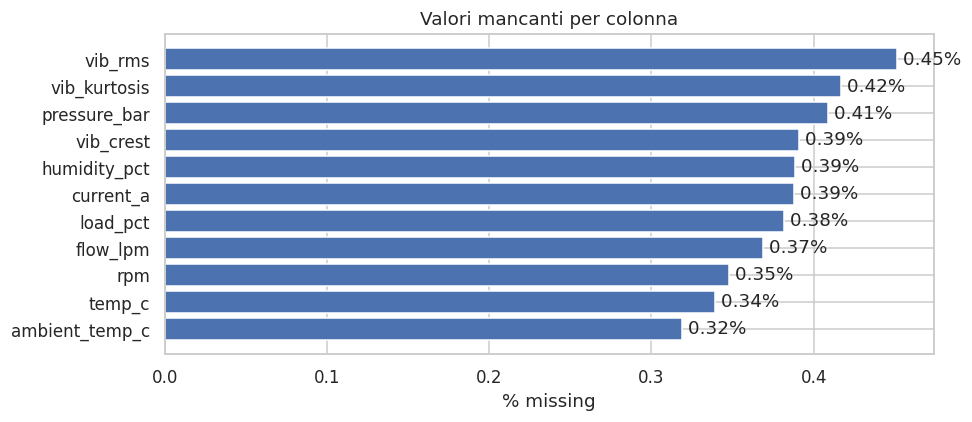

In [3]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1])
ax.set_xlabel('% missing'); ax.set_title('Valori mancanti per colonna')
for i, v in enumerate(missing_pct.values[::-1]):
    ax.text(v, i, f' {v:.2f}%', va='center')
plt.tight_layout(); plt.show()


## Distribuzione temporale

Aspettiamo: 14400 campioni per asset (= 10 giorni × 1440 minuti). Tutti gli asset coprono lo stesso periodo.

In [4]:
asset_counts = df.groupby('asset_id').size()
print('campioni per asset:')
print(asset_counts.describe())
assert (asset_counts == 14400).all(), 'Asset con copertura disallineata!'
print('[OK] tutti gli asset hanno 14400 campioni.')

campioni per asset:
count       16.0
mean     14400.0
std          0.0
min      14400.0
25%      14400.0
50%      14400.0
75%      14400.0
max      14400.0
dtype: float64
[OK] tutti gli asset hanno 14400 campioni.


## Distribuzione di regimi e label

I tre regimi (0, 1, 2) corrispondono a stati operativi distinti — questo è il segnale più forte che il clustering dovrebbe catturare. Le label `anomaly_label` (~2.4%) e `fault_code_true != 0` (~4%) sono rare e parziali: validazione "debole".

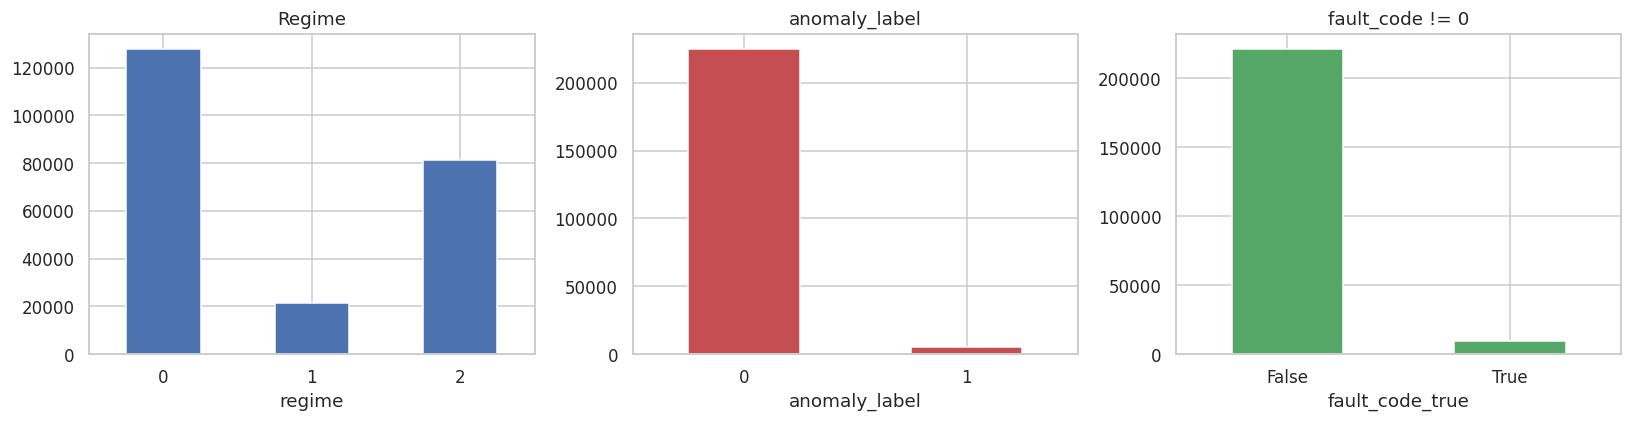

Anomalie: 2.37% dei campioni
Fault: 4.00% dei campioni


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.regime.value_counts().sort_index().plot.bar(ax=axes[0], title='Regime', color='C0')
df.anomaly_label.value_counts().plot.bar(ax=axes[1], title='anomaly_label', color='C3')
(df.fault_code_true != 0).value_counts().plot.bar(ax=axes[2], title='fault_code != 0', color='C2')
for a in axes: a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
print(f'Anomalie: {df.anomaly_label.mean():.2%} dei campioni')
print(f'Fault: {(df.fault_code_true != 0).mean():.2%} dei campioni')

## Visualizzare un asset nel tempo

Per intuizione visiva: prendiamo l'asset 0 e plottiamo `vib_rms`, evidenziando i punti etichettati come anomalia.

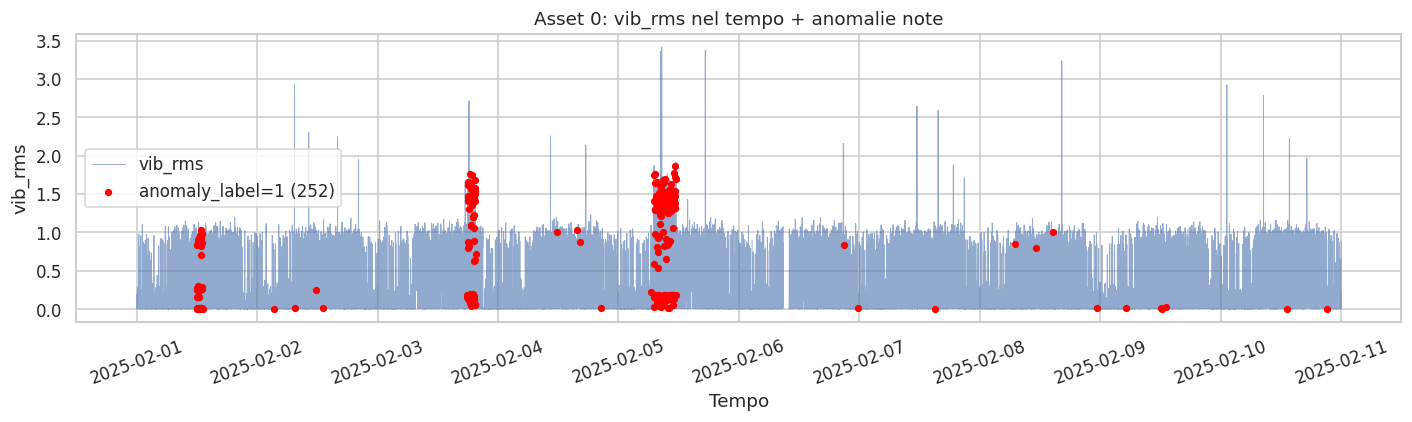

In [6]:
asset_id = 0
sub = df[df.asset_id == asset_id].sort_values('timestamp')
anom_pts = sub[sub.anomaly_label == 1]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sub.timestamp, sub.vib_rms, alpha=0.6, lw=0.6, label='vib_rms')
ax.scatter(anom_pts.timestamp, anom_pts.vib_rms, c='red', s=14,
           label=f'anomaly_label=1 ({len(anom_pts)})', zorder=5)
ax.set_xlabel('Tempo'); ax.set_ylabel('vib_rms')
ax.set_title(f'Asset {asset_id}: vib_rms nel tempo + anomalie note')
ax.legend(); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

## Conclusioni dell'EDA

- **3 regimi operativi distinti** → il clustering dovrebbe trovare almeno   3 cluster "normali" (uno per regime).
- **Missing ~3.85%** concentrati sui sensori → forward-fill per asset.
- **Label parziali**: validazione possibile ma debole. Non usarle per training.
- **Sampling regolare (1 minuto)** → ok rolling window in unità di minuti.

Vai al notebook **02_features_pipeline**.
